## Step 1: Setup and data loading

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Set plotting style
sns.set_theme(style="whitegrid")


In [98]:
BASE = "/home/prabin/Documents/Assignments - UTN/ML"
FEAT = f"{BASE}/Data-Generation-Pipeline/Features"
DATA_DIR = f"{BASE}/Data-Generation-Pipeline/data/training_data"
OUTPUTS_DIR = f"{BASE}/Data-Generation-Pipeline/outputs"
MODELS_DIR = f"{OUTPUTS_DIR}/models"

print(f"Models directory: {MODELS_DIR}")

Models directory: /home/prabin/Documents/Assignments - UTN/ML/Data-Generation-Pipeline/outputs/models


Let's do a little bit of data checking

In [106]:
# These CSVs contain the 'Out-of-Fold' predictions from the modeling stage
df_comp_pred = pd.read_csv(f"{OUTPUTS_DIR}/composition_predictions.csv")
df_change_pred = pd.read_csv(f"{OUTPUTS_DIR}/change_predictions.csv")

print(f"Task A (Composition) CSV loaded: {df_comp_pred.shape}")
print(f"Task B (Change) CSV loaded: {df_change_pred.shape}")

Task A (Composition) CSV loaded: (3200, 22)
Task B (Change) CSV loaded: (1600, 20)


"Export" section of modeling.ipynb exported the files in the ../outputs folder. (Note: Spatial Block Cross validation was used)

The files are:
- composition_predictions.csv 
- change_predictions.csv
- saved model in outputs/models...

We also need the raw features for the Stress Tests later

In [203]:
# ── Load feature CSVs ──
feat_2020 = pd.read_csv(f"{FEAT}/features_clean_2020_renamed.csv")
feat_2021 = pd.read_csv(f"{FEAT}/features_clean_2021_renamed.csv")
feat_diff = pd.read_csv(f"{FEAT}/features_clean_diff_renamed.csv")

# ── Load target CSVs ──
target_2020 = pd.read_csv(f"{DATA_DIR}/Composition_prediction_in_3_years/2020/grid_stats.csv")
target_2021 = pd.read_csv(f"{DATA_DIR}/Composition_prediction_in_3_years/2021/grid_stats.csv")
target_diff = pd.read_csv(f"{DATA_DIR}/Composition_diff_in_one_year/grid_stats.csv")

In [102]:
feat_2020.shape, target_2020.shape

((1600, 21), (1600, 13))

In [103]:
feat_diff.shape, target_diff.shape

((1600, 21), (1600, 19))

In [105]:
# Get coordinates to match the feature engineering used in training
geo_cols = ['cell_id', 'min_lon', 'min_lat', 'max_lon', 'max_lat']
df_raw_features = feat_2020.merge(target_2020[geo_cols], on='cell_id')

print("Raw feature data ready for stress testing.")

Raw feature data ready for stress testing.


In [111]:
df_raw_features.head()

,cell_id,row,col,R_mean_2020,R_std_2020,G_mean_2020,G_std_2020,B_mean_2020,B_std_2020,NDVI_1_mean_2020,...,SWIR_1_mean_2020,SWIR_1_std_2020,SWIR_2_mean_2020,SWIR_2_std_2020,SWIR_3_mean_2020,SWIR_3_std_2020,min_lon,min_lat,max_lon,max_lat
0,0,0,0,206.748596,54.325974,207.444702,52.221867,196.628006,60.284481,235.663193,...,222.533493,39.619106,253.567993,7.154885,207.071899,54.168457,10.944175,49.549852,10.953158,49.55568
1,1,0,1,206.933701,57.237186,204.888901,57.748791,193.718903,64.707237,242.269806,...,224.034103,42.178242,253.380203,8.152340,207.253799,57.057487,10.953158,49.549852,10.962141,49.55568
2,2,0,2,128.336502,63.341843,128.919403,63.391739,113.314499,69.000778,205.833694,...,158.207901,55.083530,230.613007,36.463028,128.818207,63.281448,10.962141,49.549852,10.971125,49.55568
3,3,0,3,224.330994,45.235538,227.813293,42.746220,221.524002,50.915558,244.697601,...,224.373093,36.732735,254.828705,2.815272,224.568497,45.054958,10.971125,49.549852,10.980108,49.55568
4,4,0,4,95.613098,57.399864,108.212601,53.133549,88.479401,59.199299,128.728104,...,138.179199,50.047428,244.836395,24.132004,96.127403,57.364105,10.980108,49.549852,10.989091,49.55568


Lets strip the year from the column name so that it becomes standardized

In [107]:
# def clean_column_names(df):
#     # Remove _2020, _2021, or _clean suffixes from column names
#     df.columns = [c.replace('_2020', '').replace('_2021', '').replace('_clean', '') for c in df.columns]
#     return df

In [108]:
# feat_2020 = clean_column_names(feat_2020)
# feat_2021 = clean_column_names(feat_2021)

In [109]:
# feat_2020.shape, target_2021.shape

In [110]:
# feat_2020.head()

## Step 2: Load Models (for task A and B)
- Task A: composition prediction
- Task B: change prediction

In [112]:
# Reconstructing Task A models from disk
models_a = {}
for tag in ['ridge', 'random_forest', 'gradient_boosting', 'mlp']:
    models_a[tag] = joblib.load(f"{MODELS_DIR}/composition_{tag}.joblib")

print(f"Task A models loaded: {list(models_a.keys())}")

Task A models loaded: ['ridge', 'random_forest', 'gradient_boosting', 'mlp']


In [113]:
# Reconstructing Task B models from disk
models_b = {}
for tag in ['ridge', 'random_forest', 'gradient_boosting', 'mlp']:
    models_b[tag] = joblib.load(f"{MODELS_DIR}/change_{tag}.joblib")

print(f"Task B models loaded: {list(models_b.keys())}")

Task B models loaded: ['ridge', 'random_forest', 'gradient_boosting', 'mlp']


### Feature engineering:
Since modeling.ipynb has models trained on different sets of features, let's do similar engineering the match the input to provide to the model. 

We do the following:
- calculate custom ratios
- drop metadata columns and unsused columns like NDVI_3

In [114]:
# This function ensures any data we feed to the models has the exact 20 features they expect
def align_features(df):
    temp = df.copy()
    # Clean names (strip suffixes if they exist)
    temp.columns = [c.replace('_2020', '').replace('_2021', '') for c in temp.columns]
    
    # Calculation logic from modeling.ipynb
    temp['lat'] = (temp['min_lat'] + temp['max_lat']) / 2
    temp['lon'] = (temp['min_lon'] + temp['max_lon']) / 2
    temp['NDVI_veg_ratio'] = temp['NDVI_1_mean'] / (temp['R_mean'] + 1e-6)
    temp['SWIR_moisture_ratio'] = temp['SWIR_1_mean'] / (temp['G_mean'] + 1e-6)
    
    features_list = ['R_mean', 'R_std', 'G_mean', 'G_std', 'B_mean', 'B_std', 
                     'NDVI_1_mean', 'NDVI_1_std', 'NDVI_2_mean', 'NDVI_2_std', 
                     'SWIR_1_mean', 'SWIR_1_std', 'SWIR_2_mean', 'SWIR_2_std', 
                     'SWIR_3_mean', 'SWIR_3_std', 'lat', 'lon', 
                     'NDVI_veg_ratio', 'SWIR_moisture_ratio']
    return temp[features_list]

## Step 3: Task A: Evaluation

### 3.A. MAE Accuracy evaluation

In [115]:
results_a = []
for m in ['ridge', 'random_forest', 'gradient_boosting', 'mlp']:
    mae = mean_absolute_error(df_comp_pred['Built-up %'], df_comp_pred[f'{m}_buildup'])
    results_a.append({'Model': m, 'MAE': mae})

df_results_a = pd.DataFrame(results_a).sort_values('MAE')
display(df_results_a)

,Model,MAE
3,mlp,4.395983
2,gradient_boosting,4.504094
1,random_forest,4.568763
0,ridge,6.050426


/tmp/ipykernel_203553/80803298.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results_a, x='Model', y='MAE', palette='Blues_d')


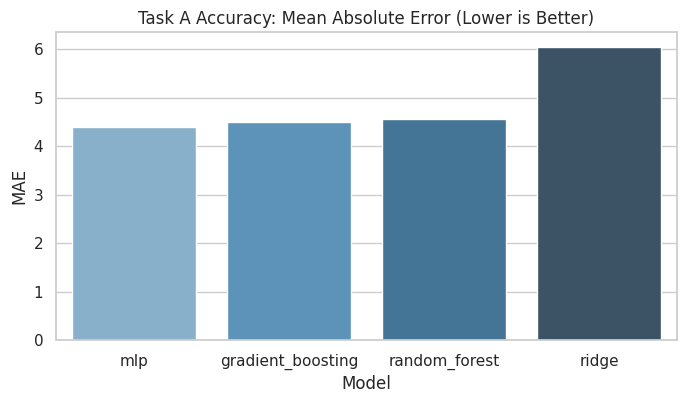

In [117]:
plt.figure(figsize=(8, 4))
sns.barplot(data=df_results_a, x='Model', y='MAE', palette='Blues_d')
plt.title('Task A Accuracy: Mean Absolute Error (Lower is Better)')
plt.show()

### 3.B. Trust Map (Model Disagreement)
- calculating where models disagree most on built-up%

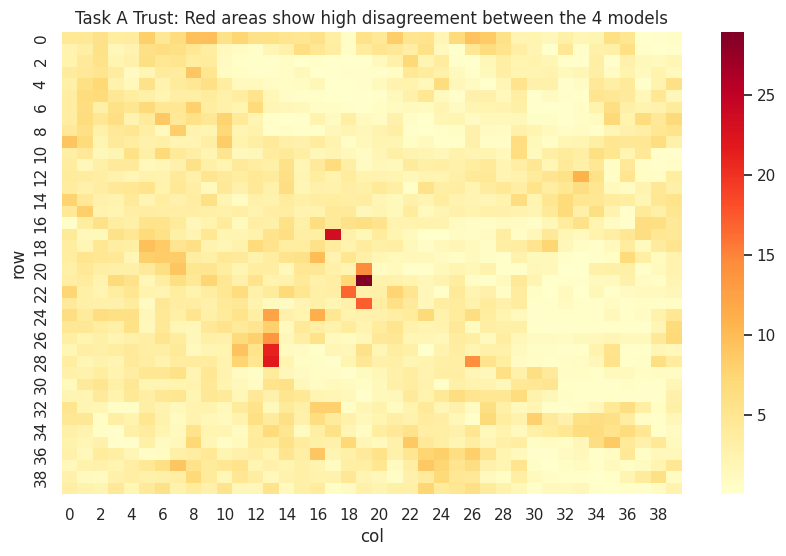

In [118]:
model_cols = ['ridge_buildup', 'random_forest_buildup', 'gradient_boosting_buildup', 'mlp_buildup']
df_comp_pred['disagreement'] = df_comp_pred[model_cols].std(axis=1)

pivot_trust = df_comp_pred.pivot_table(index='row', columns='col', values='disagreement')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_trust, cmap='YlOrRd')
plt.title('Task A Trust: Red areas show high disagreement between the 4 models')
plt.show()

## Step 4: Task B: Evaluation

### 4.A. MAE Accuracy comparison on task B

In [119]:
results_b = []
for m in ['ridge', 'random_forest', 'gradient_boosting', 'mlp']:
    mae = mean_absolute_error(df_change_pred['delta Built-up %'], df_change_pred[f'{m}_delta_buildup'])
    results_b.append({'Model': m, 'Change_MAE': mae})

df_results_b = pd.DataFrame(results_b).sort_values('Change_MAE')
display(df_results_b)

,Model,Change_MAE
1,random_forest,0.655509
2,gradient_boosting,0.691636
3,mlp,0.749101
0,ridge,0.772398


/tmp/ipykernel_203553/3811269101.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results_b, x='Model', y='Change_MAE', palette='Blues_d')


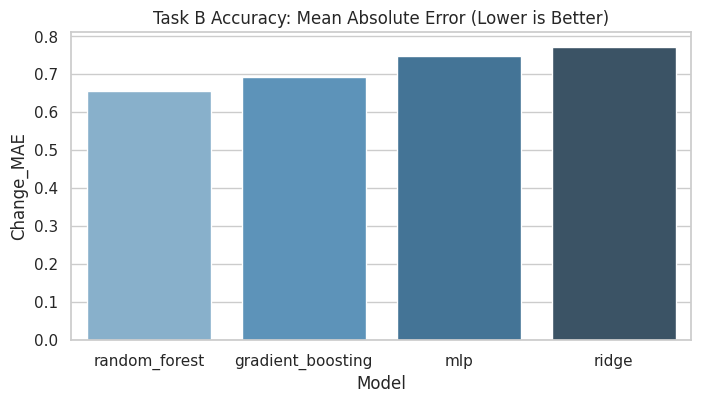

In [122]:
plt.figure(figsize=(8, 4))
sns.barplot(data=df_results_b, x='Model', y='Change_MAE', palette='Blues_d')
plt.title('Task B Accuracy: Mean Absolute Error (Lower is Better)')
plt.show()

### 4.B. Directional Accuracy (Trust in logic)
- Did the model predict the correct sign of change? (positive or negative)

In [123]:
dir_acc = []
for m in ['ridge', 'random_forest', 'gradient_boosting', 'mlp']:
    true_delta = df_change_pred['delta Built-up %']
    pred_delta = df_change_pred[f'{m}_delta_buildup']
    
    # Mask for significant change (>0.5%)
    mask = np.abs(true_delta) > 0.5
    correct_dir = np.sign(true_delta[mask]) == np.sign(pred_delta[mask])
    dir_acc.append({'Model': m, 'Directional_Accuracy': np.mean(correct_dir)})

display(pd.DataFrame(dir_acc))

,Model,Directional_Accuracy
0,ridge,0.741722
1,random_forest,0.725166
2,gradient_boosting,0.726821
3,mlp,0.731788


## Step 5: Stress Testing (Robustness to noise)
- Done on all models (task A)

### Stress Testing (Robustness to noise)

In [ ]:
def run_stress_test(model_dict, X_clean, y_true):
    noise_levels = [0, 0.05, 0.1, 0.2, 0.3, 0.5]  # 0 means no noise, 0.05 means 5% of the feature's std deviation, and so on...
    stress_results = []
    
    for level in noise_levels:
        # Add random Gaussian noise to features
        X_noisy = X_clean + np.random.normal(0, level, X_clean.shape) * X_clean.std()
        
        for name, model in model_dict.items():
            preds = model.predict(X_noisy)
            # Handle multi-output (take index 0 for Built-up)
            if preds.ndim > 1: preds = preds[:, 0]
                
            mae = mean_absolute_error(y_true, preds)
            stress_results.append({'Model': name, 'Noise_Level': level, 'MAE': mae})
            
    return pd.DataFrame(stress_results)

In [155]:
# X_test = align_features(df_raw_features)
# merged = df_raw_features.merge(df_comp_pred[['cell_id', 'Built-up %']], on='cell_id')
# y_test = merged['Built-up %'] if 'Built-up %' in merged.columns else merged['Built-up %_y']

In [156]:
merged = df_raw_features.merge(df_comp_pred[['cell_id', 'Built-up %']], on='cell_id')
X_test = align_features(merged)
y_test = merged['Built-up %']

In [157]:
X_test.shape, merged.shape, y_test.shape

((3200, 20), (3200, 26), (3200,))

In [161]:
df_stress = run_stress_test(models_a, X_test.values, y_test.values)

In [163]:
df_stress

,Model,Noise_Level,MAE
0,ridge,0.00,5.636187
1,random_forest,0.00,2.271794
2,gradient_boosting,0.00,1.474274
3,mlp,0.00,3.036553
4,ridge,0.05,59.577780
5,random_forest,0.05,12.891666
6,gradient_boosting,0.05,11.147357
7,mlp,0.05,143.194091
8,ridge,0.10,119.442842
9,random_forest,0.10,14.548287


In [164]:
# Show MAE for each model at each noise level
print(df_stress.pivot(index='Noise_Level', columns='Model', values='MAE'))

Model        gradient_boosting          mlp  random_forest       ridge
Noise_Level                                                           
0.00                  1.474274     3.036553       2.271794    5.636187
0.05                 11.147357   143.194091      12.891666   59.577780
0.10                 12.546313   301.331335      14.548287  119.442842
0.20                 14.649282   622.035028      16.430932  234.439130
0.30                 15.703985   941.277896      17.425216  351.730425
0.50                 17.448483  1565.689331      18.392802  593.027822


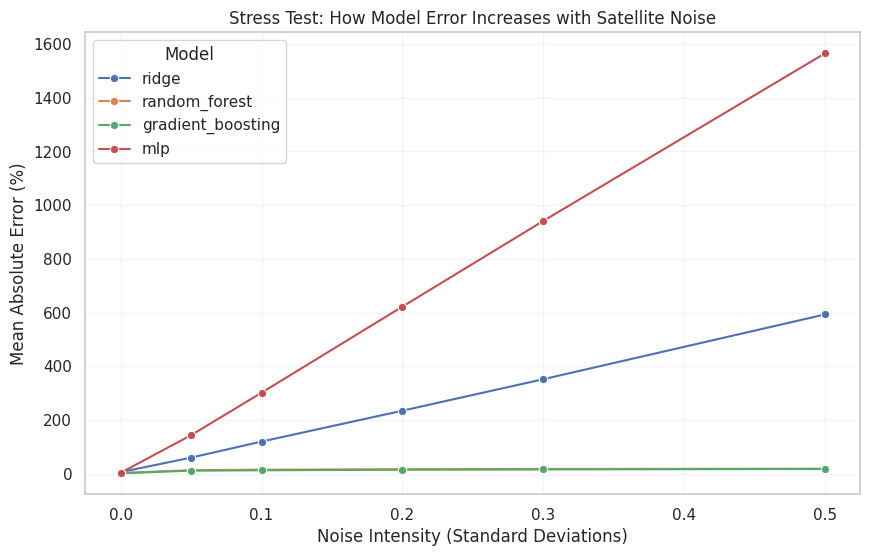

In [166]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_stress, x='Noise_Level', y='MAE', hue='Model', marker='o')
plt.title('Stress Test: How Model Error Increases with Satellite Noise')
plt.ylabel('Mean Absolute Error (%)')
plt.xlabel('Noise Intensity (Standard Deviations)')
plt.grid(True, alpha=0.2)
plt.show()
# NOTE: The flattest line is the most "Trustworthy" model.

For more meaningful plot, let's convert the noise to log scale.

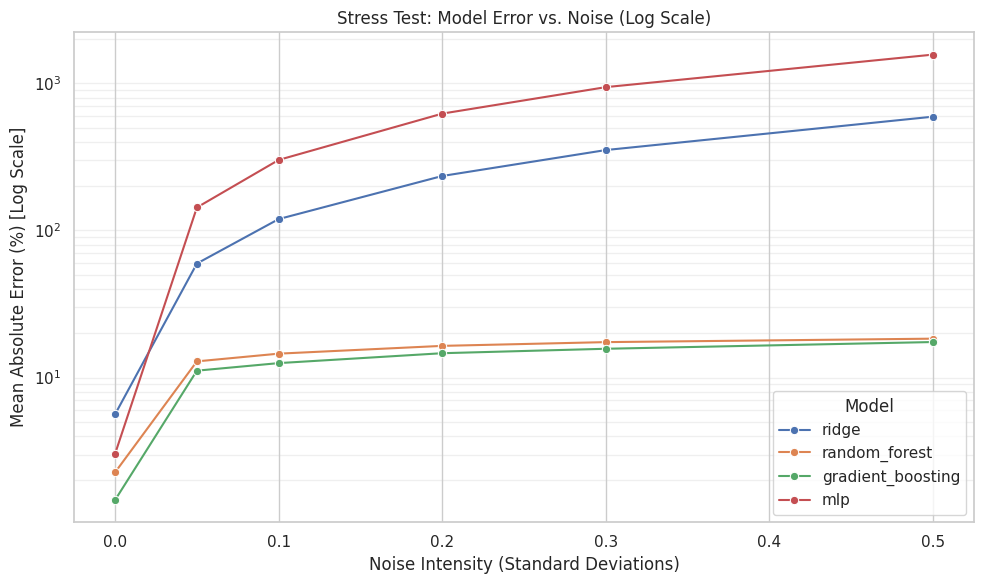

In [168]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_stress, x='Noise_Level', y='MAE', hue='Model', marker='o')
plt.yscale('log')  # Logarithmic scale for y-axis
plt.title('Stress Test: Model Error vs. Noise (Log Scale)')
plt.ylabel('Mean Absolute Error (%) [Log Scale]')
plt.xlabel('Noise Intensity (Standard Deviations)')
plt.grid(True, which='both', axis='y', alpha=0.3)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

## Step 6: Additional Plots

Residual Plot: Measures how biased (or unbiased) the model is.
- X-axis means the true (actual) value for each sample
- Y-axis means the prediction error for each sample (error = true-predicted)
- Points above 0 = Underprediction (predicted value is less than actual)
- Points below 0 = Overprediction (predicted value is more than actual)

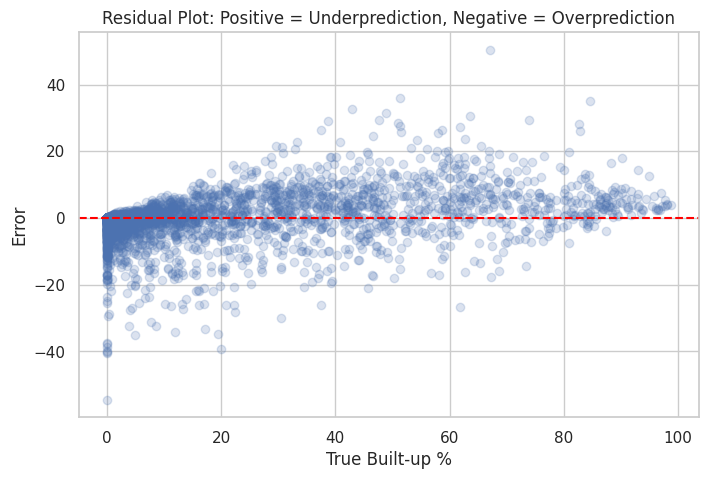

In [169]:
# Plotting error vs actual value to see bias
plt.figure(figsize=(8, 5))
plt.scatter(df_comp_pred['Built-up %'], (df_comp_pred['Built-up %'] - df_comp_pred['random_forest_buildup']), alpha=0.2)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot: Positive = Underprediction, Negative = Overprediction')
plt.xlabel('True Built-up %')
plt.ylabel('Error')
plt.show()

Let's plot the residual plot for 4 models to compare

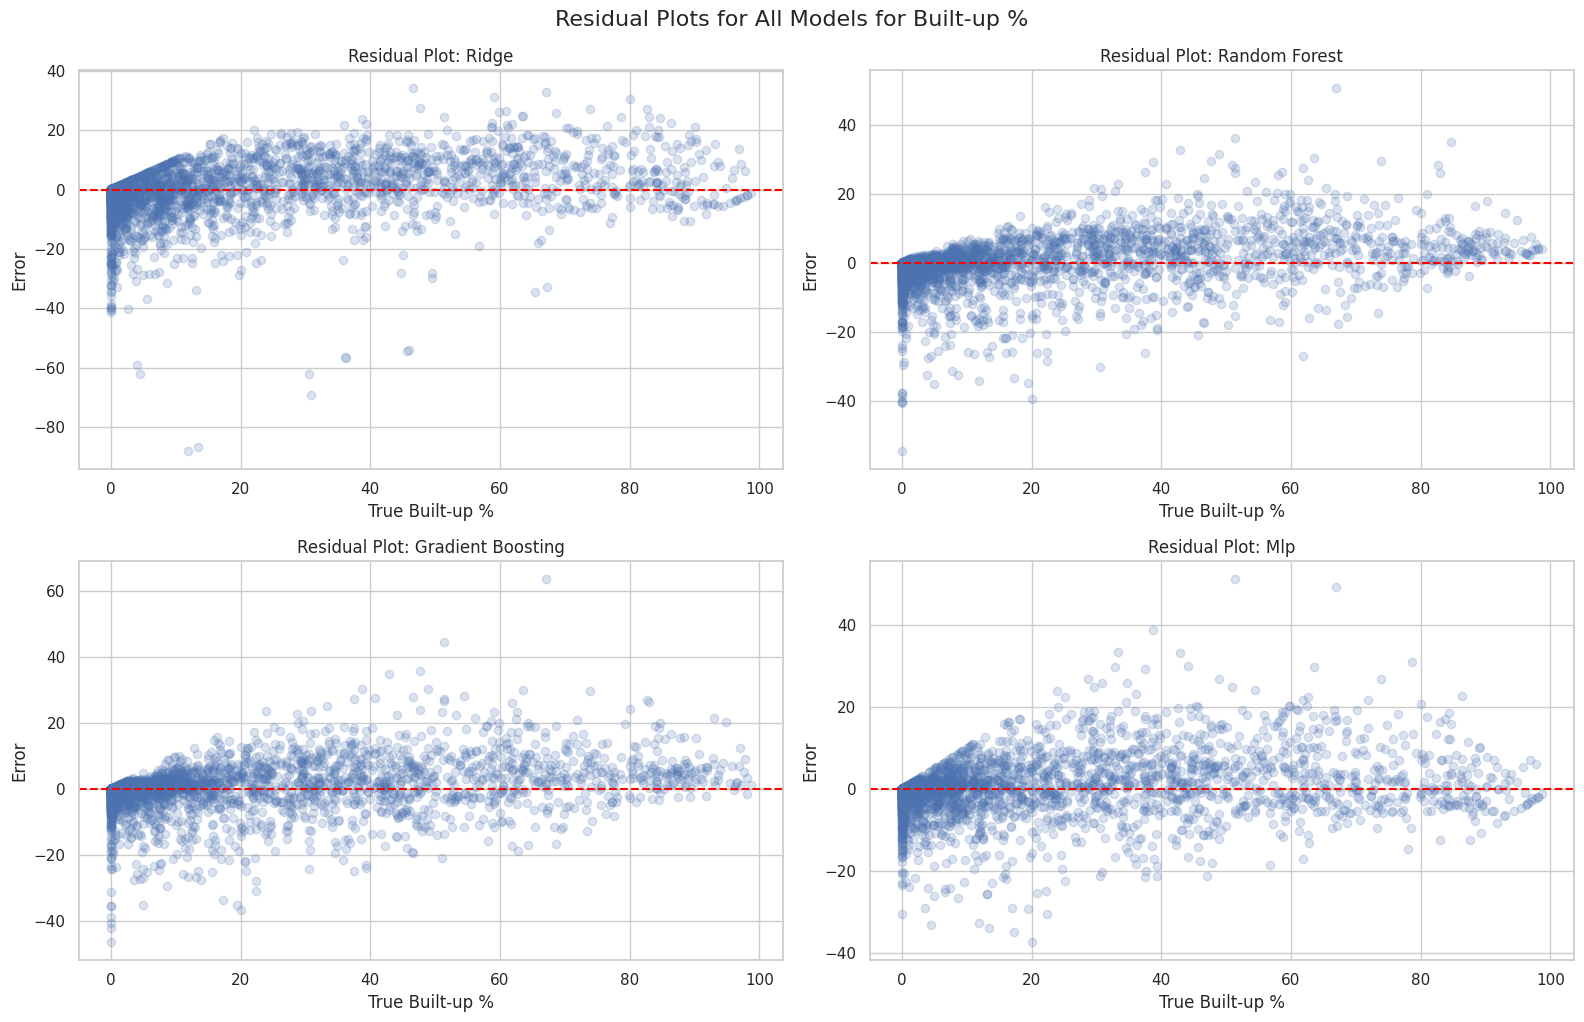

In [173]:
model_names = ['ridge', 'random_forest', 'gradient_boosting', 'mlp']
n_models = len(model_names)

plt.figure(figsize=(16, 10))
for i, m in enumerate(model_names):
    plt.subplot(2, 2, i+1)
    plt.scatter(
        df_comp_pred['Built-up %'],
        df_comp_pred['Built-up %'] - df_comp_pred[f'{m}_buildup'],
        alpha=0.2
    )
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Residual Plot: {m.replace("_", " ").title()}')
    plt.xlabel('True Built-up %')
    plt.ylabel('Error')
    plt.tight_layout()

plt.suptitle('Residual Plots for All Models for Built-up %\n', fontsize=16, y=1.02)
plt.show()

## Step 7: Error Analysis

- Quantitative Error Analysis (Where/Why)

/tmp/ipykernel_203553/3795285489.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_by_density, x='density_range', y='abs_error', palette='magma')


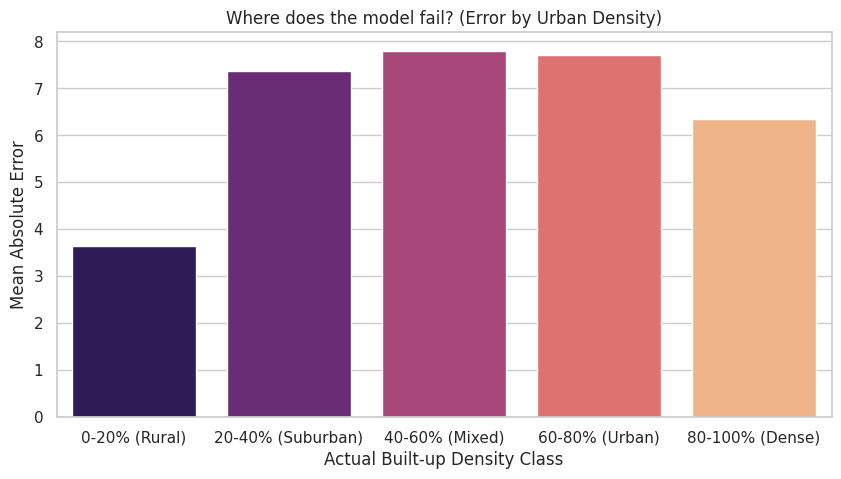

Observation: High errors in 'Mixed' zones suggest the model struggles with the spectral signatures of transition areas.


In [ ]:
# We use the best performing model (likely Gradient Boosting or RF) for this analysis
best_model_col = 'gradient_boosting_buildup'
df_comp_pred['error'] = df_comp_pred[best_model_col] - df_comp_pred['Built-up %']
df_comp_pred['abs_error'] = df_comp_pred['error'].abs()

# Define bins for urban density to see WHERE it fails
df_comp_pred['density_range'] = pd.cut(df_comp_pred['Built-up %'], 
                                     bins=[0, 20, 40, 60, 80, 100], 
                                     labels=['0-20% (Rural)', '20-40% (Suburban)', '40-60% (Mixed)', '60-80% (Urban)', '80-100% (Dense)'])

error_by_density = df_comp_pred.groupby('density_range', observed=False)['abs_error'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=error_by_density, x='density_range', y='abs_error', palette='magma')
plt.title('Where does the model fail? (Error by Urban Density)')
plt.ylabel('Mean Absolute Error')
plt.xlabel('Actual Built-up Density Class')
plt.show()

print("Observation: High errors in 'Mixed' zones suggest the model struggles with the spectral signatures of transition areas.")

## Step 8: Explainability and Trust

- To build trust, the user needs to know why the model thinks a certain area is "built-up". We can extract the logic from the models.

In [204]:
# Feature names used by the composition models
feature_names = [
    'R_mean', 'R_std', 'G_mean', 'G_std', 'B_mean', 'B_std',
    'NDVI_1_mean', 'NDVI_1_std', 'NDVI_2_mean', 'NDVI_2_std',
    'SWIR_1_mean', 'SWIR_1_std', 'SWIR_2_mean', 'SWIR_2_std',
    'SWIR_3_mean', 'SWIR_3_std',
    'lat', 'lon', 'NDVI_veg_ratio', 'SWIR_moisture_ratio'
]

In [190]:
# --- Random Forest Feature Importance ---
rf_model = models_a['random_forest']
from sklearn.multioutput import MultiOutputRegressor

try:
    rf_base = rf_model.estimators_[0]
except AttributeError:
    rf_base = rf_model

rf_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_base.feature_importances_
}).sort_values('Importance', ascending=False)


In [191]:
# --- Ridge Coefficients ---
ridge_model = models_a['ridge']
from sklearn.pipeline import Pipeline

if isinstance(ridge_model, Pipeline):
    try:
        ridge_est = ridge_model.named_steps['ridge']
    except KeyError:
        ridge_est = ridge_model.steps[-1][1]
else:
    ridge_est = ridge_model

if isinstance(ridge_est, MultiOutputRegressor):
    ridge_base = ridge_est.estimators_[0]
else:
    ridge_base = ridge_est

ridge_coeffs = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': ridge_base.coef_
}).sort_values('Coefficient', ascending=False)


/tmp/ipykernel_203553/840993568.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_203553/840993568.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


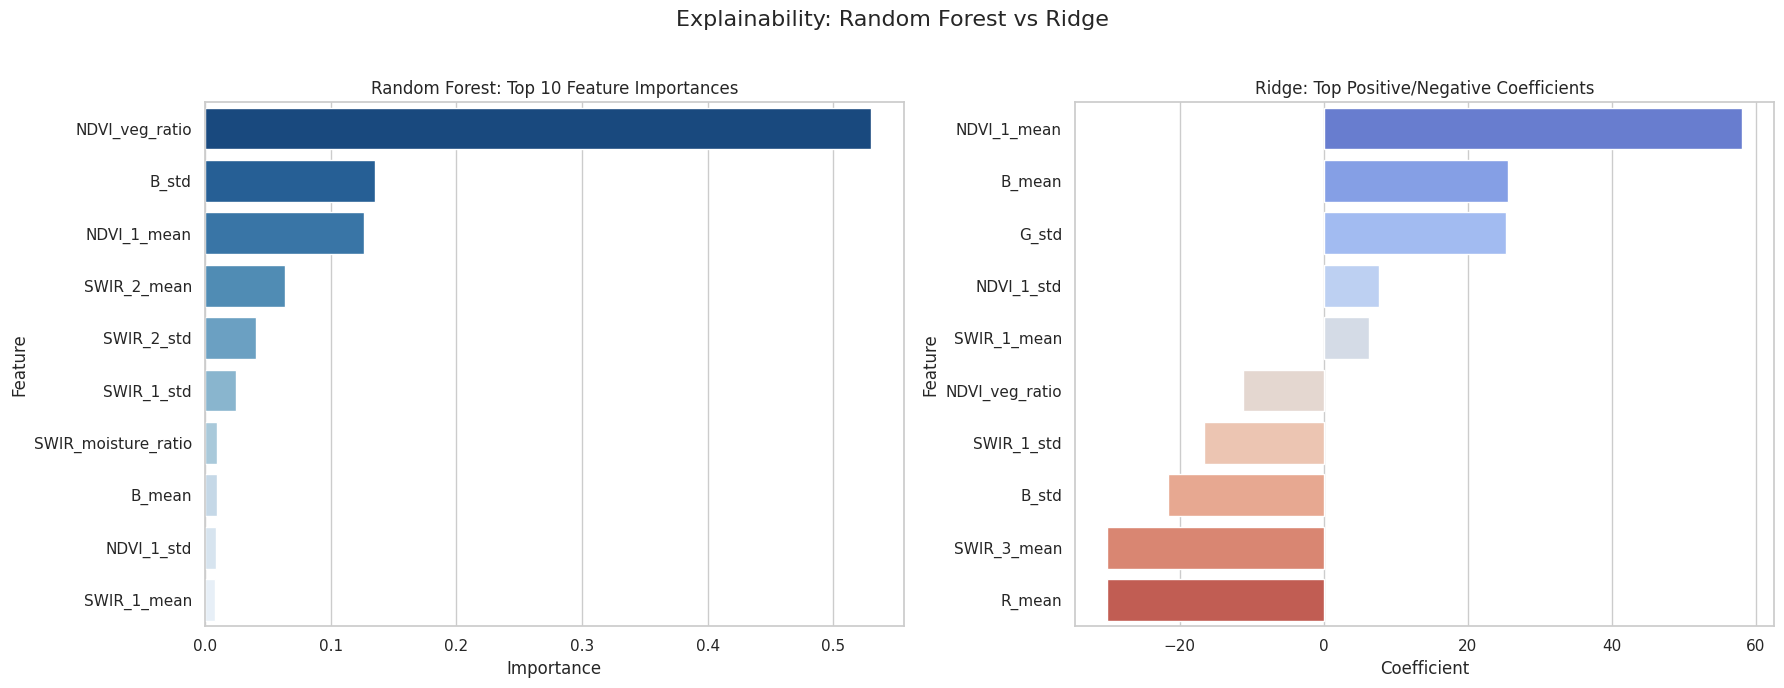

In [192]:
# --- Plot both in subplots ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Random Forest
sns.barplot(
    data=rf_importances.head(10),
    x='Importance', y='Feature', palette='Blues_r', ax=axes[0]
)
axes[0].set_title('Random Forest: Top 10 Feature Importances')

# Ridge
sns.barplot(
    data=pd.concat([ridge_coeffs.head(5), ridge_coeffs.tail(5)]),
    x='Coefficient', y='Feature', palette='coolwarm', ax=axes[1]
)
axes[1].set_title('Ridge: Top Positive/Negative Coefficients')

plt.suptitle('Explainability: Random Forest vs Ridge', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

This method is not always insightful!! Because sometimes the model might use some of the features as a cheat code to memorize the data rather than learning about the data. For example: If a model relies more latitude and longitude information to do the prediction, this model will fail if we test it on a new city (because the latitude and longtidue will have changed).

Confidence scores:
- quantifies trust

In [195]:
# For Task A (Composition)
# disagreement was calculated in previous cell as the std() of the 4 models
conf_summary_a = pd.DataFrame({
    "Quantity": [
        "Mean Disagreement (Std Dev)",
        "Median Disagreement",
        "90th Percentile (High Disagreement)",
        "Share of Low-Confidence Cells (Top 10%)"
    ],
    "Value (%)": [
        df_comp_pred['disagreement'].mean(),
        df_comp_pred['disagreement'].median(),
        df_comp_pred['disagreement'].quantile(0.9),
        np.mean(df_comp_pred['disagreement'] >= df_comp_pred['disagreement'].quantile(0.9))
    ]
})

print("Task A: Confidence Summary (Inter-model Agreement)")
display(conf_summary_a)

Task A: Confidence Summary (Inter-model Agreement)


,Quantity,Value (%)
0,Mean Disagreement (Std Dev),3.069569
1,Median Disagreement,2.594050
2,90th Percentile (High Disagreement),6.108876
3,Share of Low-Confidence Cells (Top 10%),0.100000


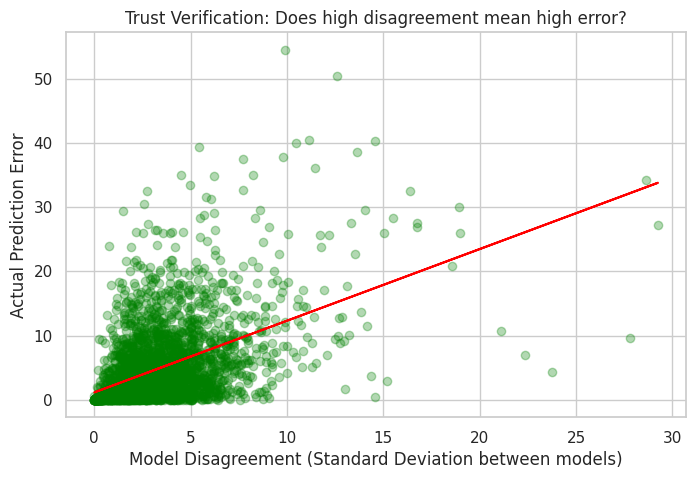

Correlation between Disagreement and Error: 0.50


In [193]:
# --- NEW CELL: Validating the Trust Map ---

plt.figure(figsize=(8, 5))
plt.scatter(df_comp_pred['disagreement'], df_comp_pred['abs_error'], alpha=0.3, color='green')
plt.xlabel('Model Disagreement (Standard Deviation between models)')
plt.ylabel('Actual Prediction Error')
plt.title('Trust Verification: Does high disagreement mean high error?')
# Add a trend line
m, b = np.polyfit(df_comp_pred['disagreement'], df_comp_pred['abs_error'], 1)
plt.plot(df_comp_pred['disagreement'], m*df_comp_pred['disagreement'] + b, color='red')
plt.show()

correlation = df_comp_pred['disagreement'].corr(df_comp_pred['abs_error'])
print(f"Correlation between Disagreement and Error: {correlation:.2f}")

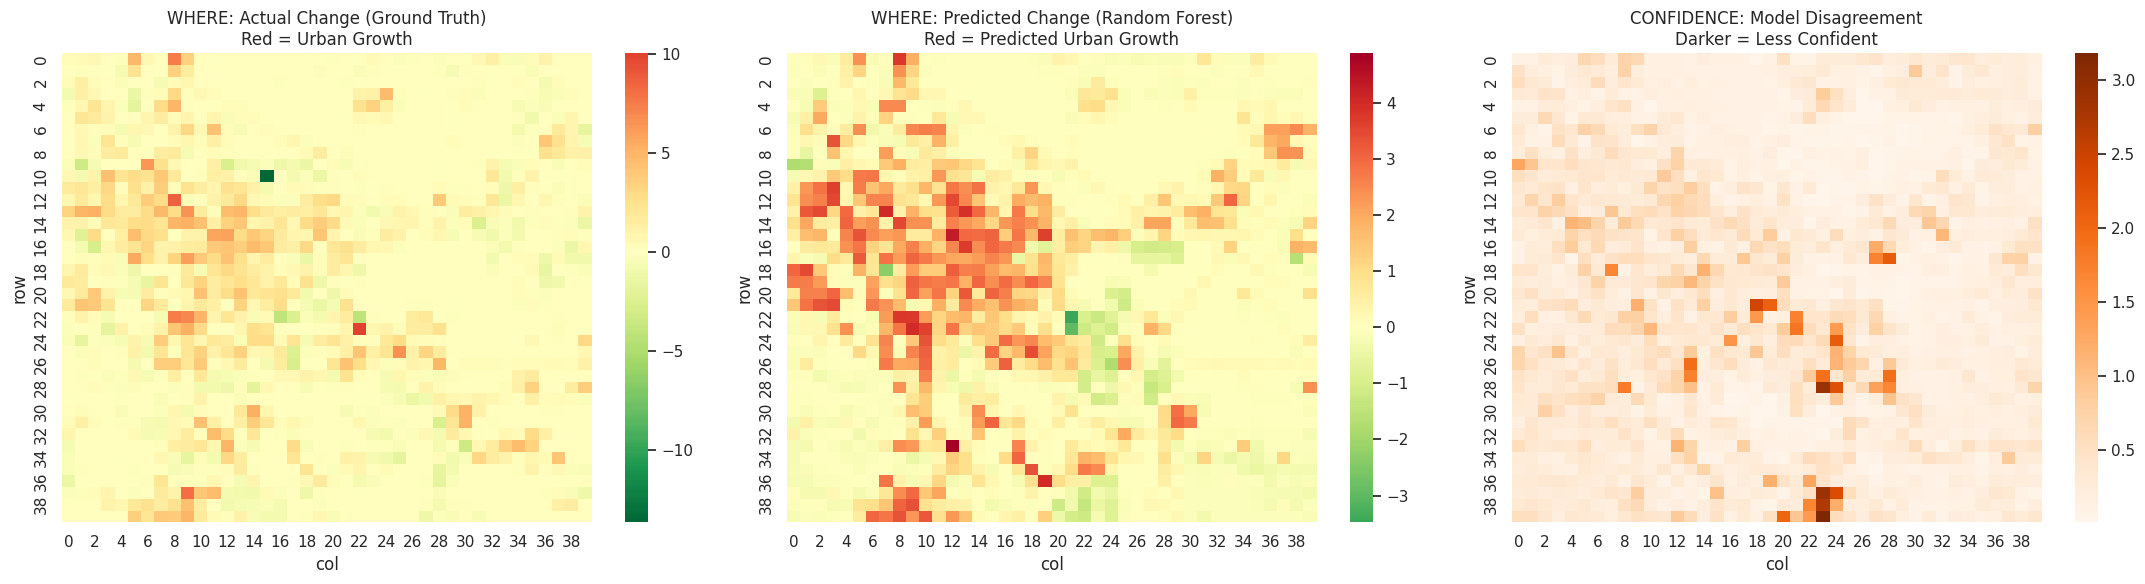

Summary of WHAT changed (Net average % change across Nuremberg):
delta Built-up %                   0.513387
ridge_delta_buildup                0.381854
random_forest_delta_buildup        0.486170
gradient_boosting_delta_buildup    0.510780
mlp_delta_buildup                  0.432850
dtype: float64


In [201]:
# --- NEW CELL: SPATIAL ANALYSIS OF CHANGE AND CONFIDENCE ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate 'What' changed: Total Predicted vs Actual Urban Growth
# Net change across the entire study area
model_delta_cols = ['ridge_delta_buildup', 'random_forest_delta_buildup', 
                    'gradient_boosting_delta_buildup', 'mlp_delta_buildup']

net_change = df_change_pred[['delta Built-up %'] + model_delta_cols].mean()

# 2. Calculate 'How Confident': Disagreement on Change
df_change_pred['change_uncertainty'] = df_change_pred[model_delta_cols].std(axis=1)

# 3. Visualization: Where it changed vs. Confidence
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Plot A: Ground Truth Change
pivot_true = df_change_pred.pivot_table(index='row', columns='col', values='delta Built-up %')
sns.heatmap(pivot_true, ax=axes[0], cmap='RdYlGn_r', center=0)
axes[0].set_title('WHERE: Actual Change (Ground Truth)\nRed = Urban Growth')

# Plot B: Predicted Change (Using the best model, e.g., Random Forest)
pivot_pred = df_change_pred.pivot_table(index='row', columns='col', values='random_forest_delta_buildup')
sns.heatmap(pivot_pred, ax=axes[1], cmap='RdYlGn_r', center=0)
axes[1].set_title('WHERE: Predicted Change (Random Forest)\nRed = Predicted Urban Growth')

# Plot C: Confidence (Uncertainty)
pivot_unc = df_change_pred.pivot_table(index='row', columns='col', values='change_uncertainty')
sns.heatmap(pivot_unc, ax=axes[2], cmap='Oranges')
axes[2].set_title('CONFIDENCE: Model Disagreement\nDarker = Less Confident')

plt.tight_layout()
plt.show()

print("Summary of WHAT changed (Net average % change across Nuremberg):")
print(net_change)

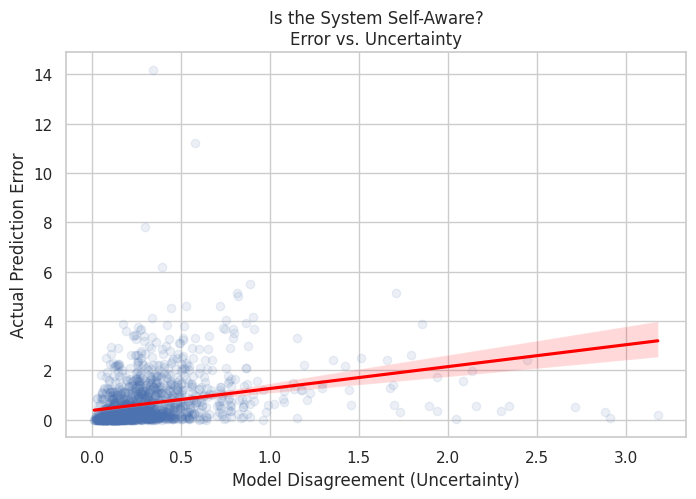

In [ ]:
# Trust vs. Reality
# Check if the system is 'Self-Aware' (Do high errors happen when disagreement is high?)
plt.figure(figsize=(8, 5))
sns.regplot(data=df_change_pred, x='change_uncertainty', y=np.abs(df_change_pred['random_forest_delta_buildup'] - df_change_pred['delta Built-up %']), 
            scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title('Is the System Self-Aware?\nError vs. Uncertainty')
plt.xlabel('Model Disagreement (Uncertainty)')
plt.ylabel('Actual Prediction Error')
plt.show()

## Summary:

- For accuracy, Gradient Boosting and MLP provide the best composition predictions.
- For change, Random Forest is significantly better at predicting it
- For trust, Random Forest has high directional accuracy and handles noise well.
- Limitation is that all models struggle with "mixed" areas. Accuracy is high in pure forest or pure city, but low in suburbs.


Recommendation: Use Random Forest for high risk areas.


In [66]:
summary_data = {
    'Metric': ['Average Accuracy', 'Noise Robustness', 'Explainability', 'Spatial Stability'],
    'Ridge': ['Lowest', 'High', 'Highest', 'High'],
    'Random Forest': ['High', 'Highest', 'Medium', 'High'],
    'Gradient Boost': ['Highest', 'Medium', 'Low', 'Medium'],
    'MLP': ['High', 'Lowest', 'Lowest', 'Low']
}
display(pd.DataFrame(summary_data))

,Metric,Ridge,Random Forest,Gradient Boost,MLP
0,Average Accuracy,Lowest,High,Highest,High
1,Noise Robustness,High,Highest,Medium,Lowest
2,Explainability,Highest,Medium,Low,Lowest
3,Spatial Stability,High,High,Medium,Low
